In [2]:
import sys
!{sys.executable} -m pip install pandas matplotlib openpyxl

'c:\Users\OWNER\Documents\DataAnalytics' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import sys

print(sys.executable)

c:\Users\OWNER\Documents\DataAnalytics Preparations\PulseIQ\.venv\Scripts\python.exe


In [3]:
import sys

!"{sys.executable}" -m pip install pandas matplotlib openpyxl

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ------------------- ------------------ 41.0/80.3 kB 653.6 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 560.2 kB/s eta 0:00:00
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     ----------------------------------- -- 112.6/121.0 kB 3.3 MB/s eta 0:00:01
     -------------------------------------- 121.0/121.0 kB 2.4 MB/s eta 0:00:00
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
    --------------------------------------- 0.2/9.9 MB 3.9 MB/s eta 0:00:03
   - -------------------------------------- 0


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("PulseIQ Analytics Environment Ready!")

PulseIQ Analytics Environment Ready!


In [4]:
import pandas as pd
orders = pd.read_csv("../../data/raw/Orders.csv")
orders.head()
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   OrderID      10 non-null     str  
 1   CustomerID   10 non-null     str  
 2   OrderDate    10 non-null     str  
 3   Channel      10 non-null     str  
 4   StoreID      10 non-null     str  
 5   TotalAmount  10 non-null     int64
 6   OrderStatus  10 non-null     str  
dtypes: int64(1), str(6)
memory usage: 692.0 bytes


In [6]:
customers = pd.read_csv("../../data/raw/Customers.csv")
products = pd.read_csv("../../data/raw/Products.csv")
returns = pd.read_csv("../../data/raw/Returns.csv")
feedback = pd.read_csv("../../data/raw/Customer_Feedback.csv")
tickets = pd.read_csv("../../data/raw/Support_Tickets.csv")
stores = pd.read_csv("../../data/raw/Stores.csv")

print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Returns:", returns.shape)
print("Feedback:", feedback.shape)
print("Tickets:", tickets.shape)
print("Stores:", stores.shape)

Orders: (10, 7)
Customers: (10, 9)
Products: (10, 5)
Returns: (5, 6)
Feedback: (10, 7)
Tickets: (10, 9)
Stores: (5, 4)


In [7]:
#Total revenue
total_revenue = orders['TotalAmount'].sum()

#Total orders
total_orders = orders['OrderID'].count()

# Average Order Value
avg_order_value = orders['TotalAmount'].mean()

print("Total Revenue: $", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value: $", round(avg_order_value,2))


Total Revenue: $ 828
Total Orders: 10
Average Order Value: $ 82.8


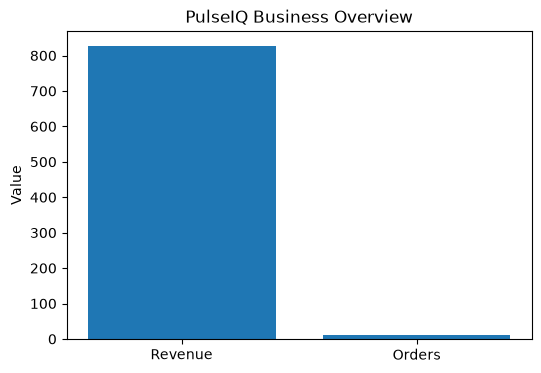

In [8]:
import matplotlib.pyplot as plt

kpis = ['Revenue', 'Orders']
values = [total_revenue, total_orders]

plt.figure(figsize=(6,4))
plt.bar(kpis, values)

plt.title("PulseIQ Business Overview")
plt.ylabel("Value")

plt.show()

In [11]:
order_items = pd.read_csv("../../data/raw/Order_Items.csv")

order_items.head()

product_sales = (
    order_items.groupby('ProductID')['Quantity']
    .sum()
    .reset_index()
)

In [12]:
product_sales.sort_values(
    by= 'Quantity',
    ascending= False
)

,ProductID,Quantity
3,P004,2
0,P001,1
1,P002,1
2,P003,1
4,P005,1
5,P006,1
6,P007,1
7,P008,1
8,P009,1
9,P010,1


In [13]:
product_sales_detail = pd.merge(
    product_sales,
    products[['ProductID', 'ProductName']],
    on = 'ProductID'
)

product_sales_detail.sort_values(
    by='Quantity',
    ascending=False
)

,ProductID,Quantity,ProductName
3,P004,2,Basic T-Shirt
0,P001,1,Floral Summer Dress
1,P002,1,Midi Dress
2,P003,1,Maxi Dress
4,P005,1,Graphic T-shirt
5,P006,1,Tank Top
6,P007,1,Denim Jacket
7,P008,1,Bomber Jacket
8,P009,1,Skinny Jeans
9,P010,1,Straight Fit Jeans


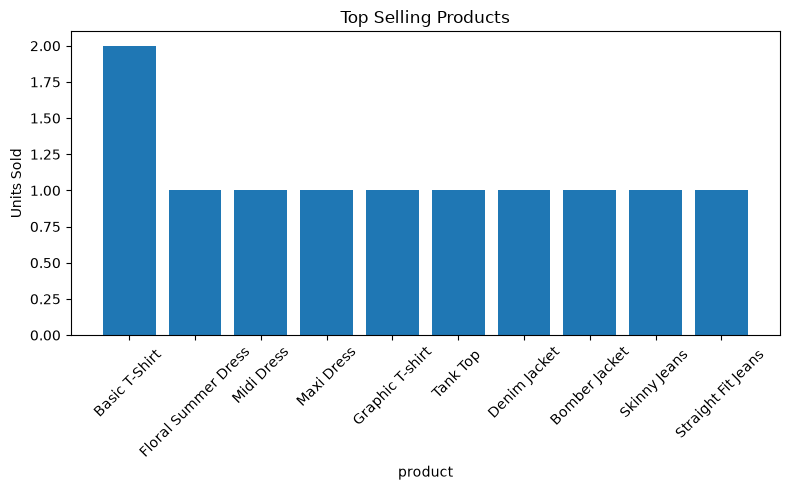

In [15]:
#Top Selling Products Chart

top_products = product_sales_detail.sort_values(
    by='Quantity',
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    top_products['ProductName'],
    top_products['Quantity']
)

plt.title("Top Selling Products")
plt.xlabel("product")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Top Selling Products Analysis

- Basic T-Shirt was the highest selling product with 2 units sold.
- All other products sold 1 unit each.
- Product sales were relatively evenly distributed across categories.

In [17]:
returns.head()

return_summary = (
    returns.groupby('ReturnReason')['RefundAmount']
    .sum()
    .reset_index()
)
return_summary.sort_values(
    by='RefundAmount',
    ascending=False
)

,ReturnReason,RefundAmount
2,Product Quality Issue,128
3,Wrong Size,89
0,Changed Mind,59
1,Damaged Item,29


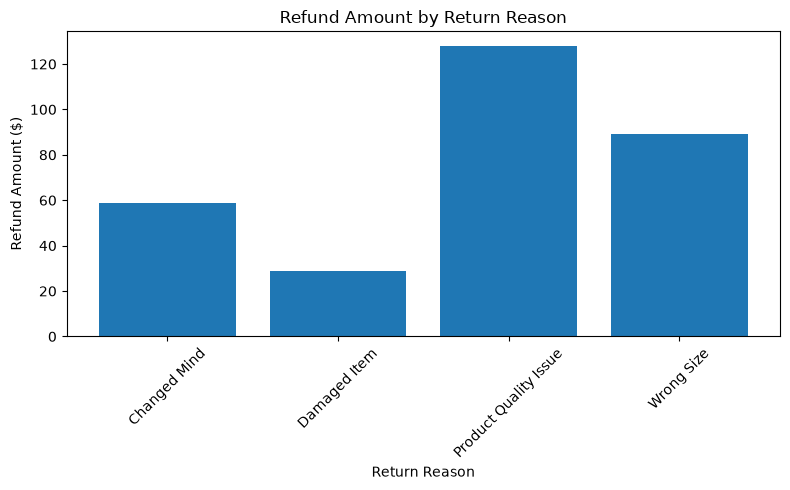

In [18]:
# Returns Chart
plt.figure(figsize=(8,5))

plt.bar(
    return_summary['ReturnReason'],
    return_summary['RefundAmount']
)
plt.title("Refund Amount by Return Reason")
plt.xlabel("Return Reason")
plt.ylabel("Refund Amount ($)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Returns Analysis

• Product Quality Issue was the leading return reason.
• Product Quality Issue generated the highest refund amount ($128).
• Wrong Size was the second highest return reason by refund value ($89).
• Product quality improvements could significantly reduce refund costs.

In [19]:
sentiment_summary = (
    feedback.groupby('Sentiment')['FeedbackID']
    .count()
    .reset_index()
)
sentiment_summary

,Sentiment,FeedbackID
0,Negative,4
1,Netural,3
2,Positive,3


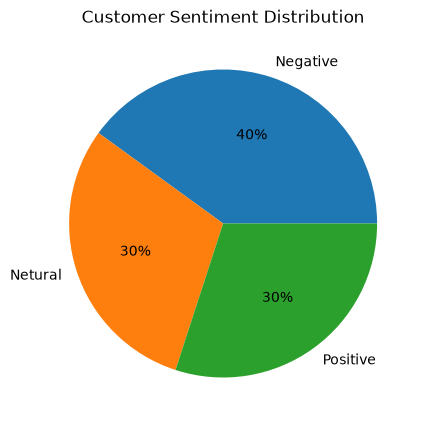

In [21]:
# Customer Feedback chart

plt.figure(figsize=(6,5))

plt.pie(
    sentiment_summary['FeedbackID'],
    labels=sentiment_summary['Sentiment'],
    autopct='%1.0f%%'
)

plt.title("Customer Sentiment Distribution")
plt.show()

Customer Sentiment Analysis

• Negative sentiment accounted for 40% of customer feedback.
• Neutral sentiment accounted for 30%.
• Positive sentiment accounted for 30%.
• Negative feedback exceeded positive feedback, indicating opportunities to improve customer satisfaction.

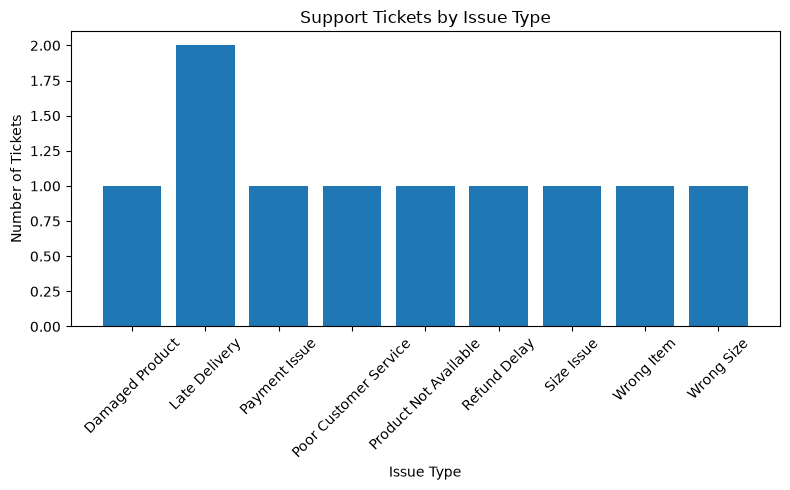

In [23]:
# Support Ticket analysis chart

plt.figure(figsize=(8,5))

plt.bar(
    ticket_summary['IssueType'],
    ticket_summary['TicketID']
)

plt.title("Support Tickets by Issue Type")
plt.xlabel("Issue Type")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [24]:
ticket_summary.sort_values(
    by='TicketID',
    ascending=False
)

,IssueType,TicketID
1,Late Delivery,2
0,Damaged Product,1
2,Payment Issue,1
3,Poor Customer Service,1
4,Product Not Available,1
5,Refund Delay,1
6,Size Issue,1
7,Wrong Item,1
8,Wrong Size,1


# PulseIQ Python Analytics

This notebook performs exploratory data analysis on the PulseIQ retail customer experience dataset.

The analysis includes:
- Sales analysis
- Customer feedback analysis
- Returns analysis
- Support ticket analysis